# Non-ML Full Analysis

Notebook-first analysis for classic (indicator-based) results in `database/results.parquet`.
This notebook builds benchmark-aware stats and inline plots to answer performance questions directly from the data.

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'database' / 'results.parquet').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_PATH = PROJECT_ROOT / 'database' / 'results.parquet'
OUTPUT_DIR = PROJECT_ROOT / 'analysis' / 'results' / 'non_ml_full'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Results path:', RESULTS_PATH)
print('Output dir  :', OUTPUT_DIR)

Results path: C:\Users\ruben\OneDrive\Documenten\Coding\paper\indicator-stock-prediction-study\database\results.parquet
Output dir  : C:\Users\ruben\OneDrive\Documenten\Coding\paper\indicator-stock-prediction-study\analysis\results\non_ml_full


In [8]:
df = pd.read_parquet(RESULTS_PATH)
print('Rows:', len(df))
print('Columns:', len(df.columns))
display(df.head(3))

Rows: 4725
Columns: 35


,strategy,symbol,interval,parameters,return,sharpe,trades,win_rate,start_date,end_date,...,avg_trade_pnl,avg_win_pnl,avg_loss_pnl,profit_factor,long_trades,short_trades,long_win_rate,short_win_rate,backtest_version,risk_profile
0,DMAC,AAPL,1d,"{""adx_period"": 7, ""adx_threshold"": 20, ""pfast""...",-88.212594,-0.515521,102,0.215686,2006-05-10,2026-03-25,...,-8.673277,31.155146,-19.626093,0.436545,0,102,0.0,0.215686,long_short_risk_v4_slippage,"{""atr_len_for_sizing"": 14, ""default_stop_atr"":..."
1,DMAC,AAPL,1d,"{""adx_period"": 14, ""adx_threshold"": 20, ""pfast...",-61.036253,-0.294377,56,0.267857,2006-05-10,2026-03-25,...,-10.899331,42.667456,-30.496936,0.511856,0,56,0.0,0.267857,long_short_risk_v4_slippage,"{""atr_len_for_sizing"": 14, ""default_stop_atr"":..."
2,DMAC,AAPL,1d,"{""adx_period"": 7, ""adx_threshold"": 20, ""pfast""...",-50.632631,-0.290901,22,0.227273,2006-05-10,2026-03-25,...,-23.014832,61.317004,-47.818314,0.377144,0,22,0.0,0.227273,long_short_risk_v4_slippage,"{""atr_len_for_sizing"": 14, ""default_stop_atr"":..."


In [9]:
# Optional scope filters
BACKTEST_VERSION = ''  # example: 'long_short_risk_v4_slippage'
RISK_PROFILE = ''      # exact JSON string if needed
TOP_N = 50

work = df.copy()
if BACKTEST_VERSION:
    work = work[work['backtest_version'] == BACKTEST_VERSION]
elif 'backtest_version' in work.columns and not work.empty:
    work = work[work['backtest_version'] == work['backtest_version'].mode().iloc[0]]

if RISK_PROFILE:
    work = work[work['risk_profile'] == RISK_PROFILE]

numeric_cols = [
    'return', 'sharpe', 'trades', 'win_rate', 'market_gain', 'excess_return',
    'benchmark_gain', 'benchmark_excess_return', 'annualized_return',
    'max_drawdown_pct', 'calmar', 'profit_factor'
]
for c in numeric_cols:
    if c in work.columns:
        work[c] = pd.to_numeric(work[c], errors='coerce')

work = work.dropna(subset=['strategy', 'symbol', 'interval'])

work['return_rank'] = work['return'].rank(pct=True, ascending=True)
work['sharpe_rank'] = work['sharpe'].rank(pct=True, ascending=True)
work['benchmark_excess_rank'] = work['benchmark_excess_return'].rank(pct=True, ascending=True)
work['drawdown_rank'] = work['max_drawdown_pct'].rank(pct=True, ascending=False)
work['composite_score'] = work[['return_rank','sharpe_rank','benchmark_excess_rank','drawdown_rank']].mean(axis=1)

print('Scoped rows:', len(work))
print('Strategies:', work['strategy'].nunique(), '| Symbols:', work['symbol'].nunique(), '| Intervals:', work['interval'].nunique())

Scoped rows: 4725
Strategies: 13 | Symbols: 15 | Intervals: 1


In [10]:
def group_stats(frame, group_col):
    out = (
        frame.groupby(group_col, dropna=False)
        .agg(
            runs=('strategy', 'size'),
            mean_return=('return', 'mean'),
            median_return=('return', 'median'),
            mean_sharpe=('sharpe', 'mean'),
            median_sharpe=('sharpe', 'median'),
            mean_drawdown_pct=('max_drawdown_pct', 'mean'),
            mean_win_rate=('win_rate', 'mean'),
            mean_trades=('trades', 'mean'),
            mean_benchmark_excess=('benchmark_excess_return', 'mean'),
            median_benchmark_excess=('benchmark_excess_return', 'median'),
        )
        .reset_index()
    )
    out['pct_positive_return'] = frame.groupby(group_col)['return'].apply(lambda s: (s > 0).mean()).values
    out['pct_beat_benchmark'] = frame.groupby(group_col)['benchmark_excess_return'].apply(lambda s: (s > 0).mean()).values
    return out

strategy_stats = group_stats(work, 'strategy').sort_values('median_benchmark_excess', ascending=False)
symbol_stats = group_stats(work, 'symbol').sort_values('median_benchmark_excess', ascending=False)
interval_stats = group_stats(work, 'interval').sort_values('median_benchmark_excess', ascending=False)
strategy_interval_stats = group_stats(work.assign(strategy_interval=work['strategy'] + ' | ' + work['interval']), 'strategy_interval').sort_values('median_benchmark_excess', ascending=False)

top_runs = work.sort_values('composite_score', ascending=False).head(TOP_N)
best_per_symbol_interval = (
    work.sort_values('composite_score', ascending=False)
    .groupby(['symbol', 'interval'], as_index=False)
    .first()
)

display(strategy_stats.head(10))
display(symbol_stats.head(10))
display(interval_stats)
display(top_runs[['strategy','symbol','interval','return','sharpe','max_drawdown_pct','benchmark_excess_return','trades','win_rate','parameters','composite_score']].head(20))

,strategy,runs,mean_return,median_return,mean_sharpe,median_sharpe,mean_drawdown_pct,mean_win_rate,mean_trades,mean_benchmark_excess,median_benchmark_excess,pct_positive_return,pct_beat_benchmark
9,RSI_MA,540,-19.859860,-15.382737,-0.555268,-0.481614,33.021988,0.479234,82.751852,-381.406579,-397.649784,0.248148,0.000000
11,SMC_SWEEP_OBFVG,405,0.064509,0.000000,-0.629452,0.000000,0.403567,0.100000,0.237037,-361.482210,-397.997494,0.103704,0.000000
10,RSI_PULLBACK,90,-2.592935,0.000000,-0.282539,-0.003999,10.580028,0.147445,2.788889,-364.139654,-398.310468,0.222222,0.000000
0,ATR_VOL_BO,405,2.064907,0.000000,-0.535901,0.000000,2.216760,0.177366,0.822222,-359.481812,-398.310468,0.200000,0.000000
1,BBANDS_MR,240,-3.511191,-1.948203,-1.432008,-1.312812,5.780941,0.243090,5.433333,-365.057910,-398.484876,0.208333,0.000000
12,VWAP_RECLAIM,405,-17.481054,-18.408712,-0.313933,-0.332810,38.500807,0.216263,48.382716,-379.027772,-409.907540,0.177778,0.007407
5,HHHL_STRUCT_BO,405,-21.916137,-26.659581,-0.213160,-0.223163,52.741154,0.325109,27.851852,-383.462856,-413.616995,0.192593,0.022222
7,MA200_PULLBACK,405,-21.634858,-21.406635,-0.174608,-0.180298,48.368738,0.277975,30.264198,-383.181577,-415.160953,0.269136,0.000000
6,INSIDE_BAR_CONT,405,-24.265005,-32.644306,-0.270062,-0.247420,50.151267,0.233749,34.688889,-385.811724,-418.426582,0.232099,0.000000
2,DMAC,240,-33.349511,-40.590167,-0.313859,-0.342350,51.126437,0.217100,35.116667,-394.896230,-424.016373,0.170833,0.000000


,symbol,runs,mean_return,median_return,mean_sharpe,median_sharpe,mean_drawdown_pct,mean_win_rate,mean_trades,mean_benchmark_excess,median_benchmark_excess,pct_positive_return,pct_beat_benchmark
4,ETH-USD,315,5.858681,-0.047454,-0.062100,0.000000,52.101576,0.346478,32.942857,-149.184598,-155.090733,0.361905,0.047619
3,BTC-USD,315,-19.144194,-24.720628,-0.112224,-0.046244,49.839270,0.289693,43.187302,-248.480669,-254.057103,0.244444,0.000000
5,EURUSD=X,315,-3.416996,0.000000,-0.372395,-0.138619,16.450265,0.316576,54.130159,-366.923701,-363.506705,0.346032,0.000000
10,JPYUSD=X,315,0.172025,0.000000,-0.526154,-0.221328,15.830148,0.319076,56.584127,-363.334680,-363.506705,0.438095,0.000000
6,GBPUSD=X,315,-5.571961,-3.432990,-0.434035,-0.280025,18.164003,0.295112,54.669841,-369.078666,-366.939695,0.257143,0.000000
2,AUDUSD=X,315,-7.957889,-7.516769,-0.322431,-0.213990,20.736840,0.289392,54.346032,-371.464594,-371.023474,0.190476,0.000000
12,USO,315,4.036631,0.000000,-0.200841,-0.040133,45.187003,0.297476,65.907937,-394.273837,-398.310468,0.384127,0.000000
14,^GSPC,315,-23.618616,-23.026646,-0.764892,-0.292229,35.221897,0.201212,40.923810,-421.929084,-421.337114,0.092063,0.000000
7,GLD,315,-27.292254,-25.669608,-0.560545,-0.468949,33.066675,0.283063,54.660317,-425.602722,-423.980076,0.092063,0.000000
13,^DJI,315,-30.693841,-28.905437,-0.733886,-0.454538,38.873645,0.197260,43.352381,-429.004309,-427.215905,0.047619,0.000000


,interval,runs,mean_return,median_return,mean_sharpe,median_sharpe,mean_drawdown_pct,mean_win_rate,mean_trades,mean_benchmark_excess,median_benchmark_excess,pct_positive_return,pct_beat_benchmark
0,1d,4725,-20.862474,-13.711533,-0.415492,-0.264642,38.321584,0.266194,47.988995,-382.409192,-398.310468,0.188783,0.003175


,strategy,symbol,interval,return,sharpe,max_drawdown_pct,benchmark_excess_return,trades,win_rate,parameters,composite_score
4503,ATR_VOL_BO,ETH-USD,1d,36.614983,0.293812,5.535384,-118.428296,2,1.000000,"{""atr_expansion_mult"": 1.3, ""atr_len"": 12, ""br...",0.931852
4504,ATR_VOL_BO,ETH-USD,1d,36.614983,0.293812,5.535384,-118.428296,2,1.000000,"{""atr_expansion_mult"": 1.3, ""atr_len"": 12, ""br...",0.931852
4505,ATR_VOL_BO,ETH-USD,1d,36.614983,0.293812,5.535384,-118.428296,2,1.000000,"{""atr_expansion_mult"": 1.3, ""atr_len"": 12, ""br...",0.931852
4427,RSI_MA,ETH-USD,1d,35.517742,0.277692,7.440892,-119.525537,6,1.000000,"{""buy_rsi"": 35, ""ma"": 50, ""sell_rsi"": 40}",0.926455
4501,ATR_VOL_BO,ETH-USD,1d,37.577060,0.269114,11.093261,-117.466219,3,1.000000,"{""atr_expansion_mult"": 1.2, ""atr_len"": 12, ""br...",0.920265
4500,ATR_VOL_BO,ETH-USD,1d,37.577060,0.269114,11.093261,-117.466219,3,1.000000,"{""atr_expansion_mult"": 1.2, ""atr_len"": 12, ""br...",0.920265
4502,ATR_VOL_BO,ETH-USD,1d,37.577060,0.269114,11.093261,-117.466219,3,1.000000,"{""atr_expansion_mult"": 1.2, ""atr_len"": 12, ""br...",0.920265
4426,RSI_MA,ETH-USD,1d,26.722030,0.223020,7.440892,-128.321249,7,1.000000,"{""buy_rsi"": 35, ""ma"": 50, ""sell_rsi"": 35}",0.920159
4196,ATR_VOL_BO,BTC-USD,1d,49.634795,0.252852,8.052555,-179.701680,4,0.750000,"{""atr_expansion_mult"": 1.2, ""atr_len"": 14, ""br...",0.918307
4195,ATR_VOL_BO,BTC-USD,1d,49.634795,0.252852,8.052555,-179.701680,4,0.750000,"{""atr_expansion_mult"": 1.2, ""atr_len"": 14, ""br...",0.918307


In [11]:
# Optional table exports (no image files saved)
strategy_stats.to_csv(OUTPUT_DIR / 'strategy_stats.csv', index=False)
symbol_stats.to_csv(OUTPUT_DIR / 'symbol_stats.csv', index=False)
interval_stats.to_csv(OUTPUT_DIR / 'interval_stats.csv', index=False)
strategy_interval_stats.to_csv(OUTPUT_DIR / 'strategy_interval_stats.csv', index=False)
top_runs.to_csv(OUTPUT_DIR / 'top_runs_composite.csv', index=False)
best_per_symbol_interval.to_csv(OUTPUT_DIR / 'best_run_per_symbol_interval.csv', index=False)
print('Saved CSV tables to', OUTPUT_DIR)

Saved CSV tables to C:\Users\ruben\OneDrive\Documenten\Coding\paper\indicator-stock-prediction-study\analysis\results\non_ml_full


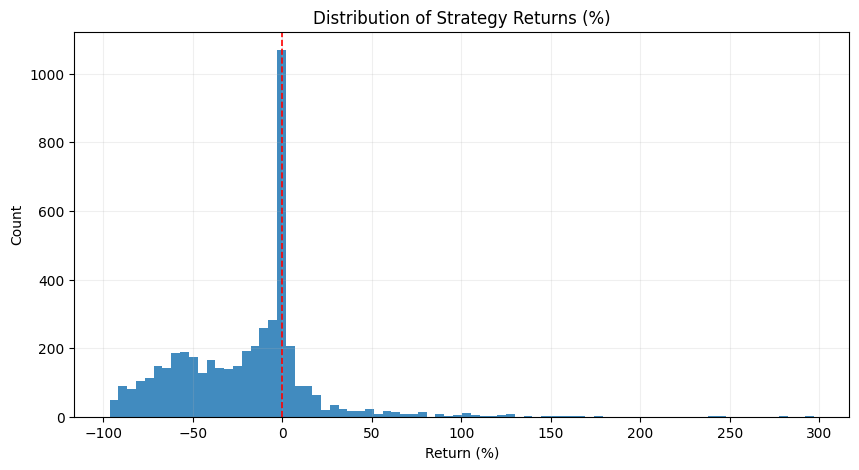

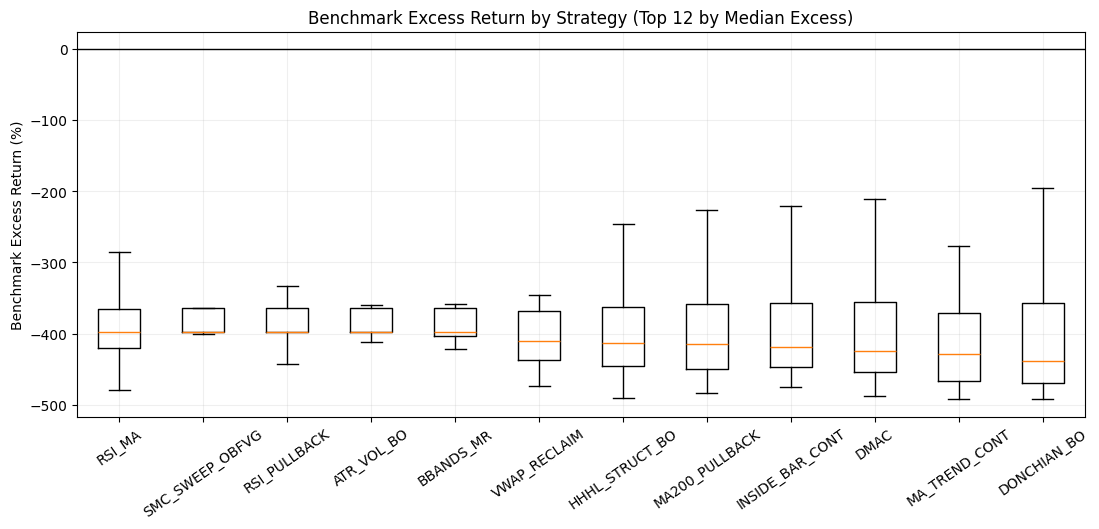

In [12]:
# Inline plots only (no .png writes)
plt.figure(figsize=(10, 5))
plt.hist(work['return'].dropna(), bins=80, alpha=0.85)
plt.axvline(0, color='red', linestyle='--', linewidth=1.2)
plt.title('Distribution of Strategy Returns (%)')
plt.xlabel('Return (%)')
plt.ylabel('Count')
plt.grid(alpha=0.2)
plt.show()

top_strats = strategy_stats.sort_values('median_benchmark_excess', ascending=False)['strategy'].head(12).tolist()
box_df = work[work['strategy'].isin(top_strats)]
data = [box_df[box_df['strategy'] == s]['benchmark_excess_return'].dropna().values for s in top_strats]

plt.figure(figsize=(13, 5))
plt.boxplot(data, tick_labels=top_strats, showfliers=False)
plt.axhline(0, color='black', linewidth=1)
plt.title('Benchmark Excess Return by Strategy (Top 12 by Median Excess)')
plt.ylabel('Benchmark Excess Return (%)')
plt.xticks(rotation=35)
plt.grid(alpha=0.2)
plt.show()

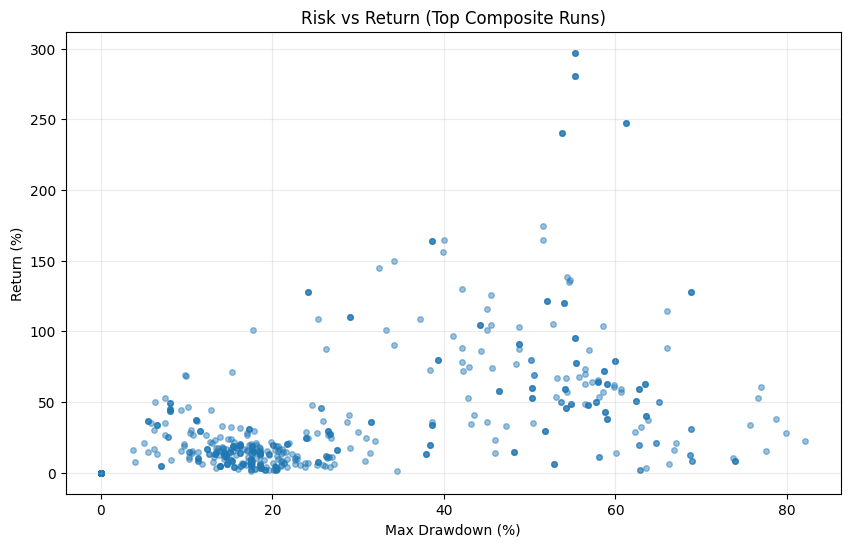

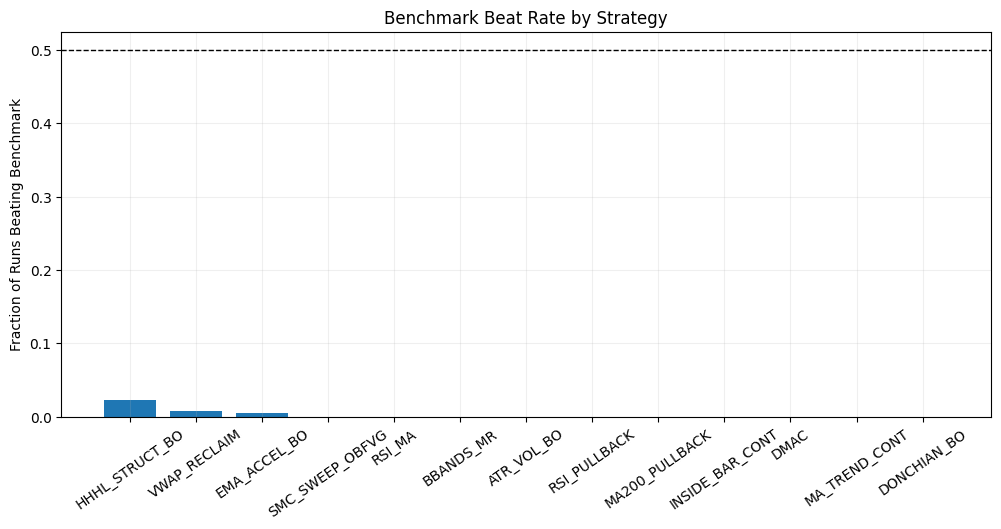

In [13]:
plot_df = work.sort_values('composite_score', ascending=False).head(min(1200, len(work)))

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['max_drawdown_pct'], plot_df['return'], alpha=0.45, s=16)
plt.title('Risk vs Return (Top Composite Runs)')
plt.xlabel('Max Drawdown (%)')
plt.ylabel('Return (%)')
plt.grid(alpha=0.25)
plt.show()

bar = strategy_stats.sort_values('pct_beat_benchmark', ascending=False)
plt.figure(figsize=(12, 5))
plt.bar(bar['strategy'], bar['pct_beat_benchmark'])
plt.axhline(0.5, color='black', linestyle='--', linewidth=1)
plt.title('Benchmark Beat Rate by Strategy')
plt.ylabel('Fraction of Runs Beating Benchmark')
plt.xticks(rotation=35)
plt.grid(alpha=0.2)
plt.show()

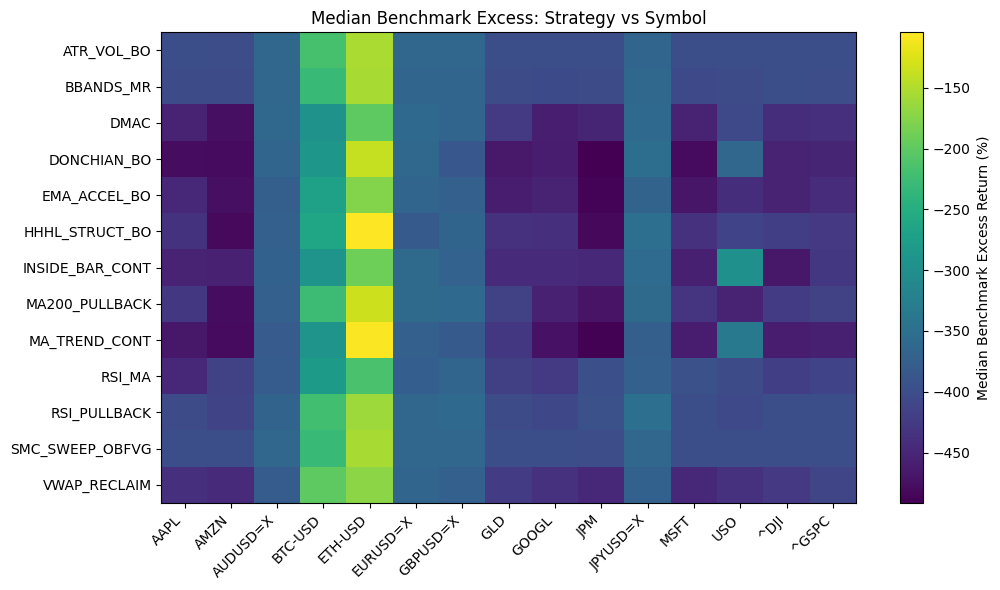

In [14]:
heat = work.pivot_table(index='strategy', columns='symbol', values='benchmark_excess_return', aggfunc='median')

plt.figure(figsize=(max(10, 0.7 * len(heat.columns)), 6))
img = plt.imshow(heat.values, aspect='auto')
plt.yticks(np.arange(len(heat.index)), heat.index)
plt.xticks(np.arange(len(heat.columns)), heat.columns, rotation=45, ha='right')
plt.title('Median Benchmark Excess: Strategy vs Symbol')
cbar = plt.colorbar(img)
cbar.set_label('Median Benchmark Excess Return (%)')
plt.tight_layout()
plt.show()

In [ ]:
# Quick textual summary to answer core questions
positive_rate = (work['return'] > 0).mean()
beat_rate = (work['benchmark_excess_return'] > 0).mean()

print(f'Runs analyzed: {len(work)}')
print(f'Positive return rate: {positive_rate:.2%}')
print(f'Benchmark beat rate: {beat_rate:.2%}')
print(f'Median return: {work["return"].median():.2f}%')
print(f'Median benchmark excess: {work["benchmark_excess_return"].median():.2f}%')
print(f'Median max drawdown: {work["max_drawdown_pct"].median():.2f}%')

Runs analyzed: 4725
Positive return rate: 18.88%
Benchmark beat rate: 0.32%
Median return: -13.71%
Median benchmark excess: -398.31%
Median max drawdown: 35.28%


: 